In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

df = pd.read_csv("complaints.csv", nrows=100000)

# Clean column names
df.columns = df.columns.str.lower().str.replace(" ", "_").str.replace("?", "")

# Convert dates
df['date_received'] = pd.to_datetime(df['date_received'])
df['date_sent_to_company'] = pd.to_datetime(df['date_sent_to_company'])

# Create response time
df['response_time'] = (df['date_sent_to_company'] - df['date_received']).dt.days

# Create consumer relief
df['consumer_relief'] = df['company_response_to_consumer'].apply(
    lambda x: 1 if 'relief' in str(x).lower() else 0
)

# Clean data
df = df.dropna(subset=['response_time', 'consumer_relief'])
df = df[df['response_time'] >= 0]

In [4]:
#Create Dummies 
df_dummies = pd.get_dummies(df, columns=['product'], drop_first=True)

product_cols = [col for col in df_dummies.columns if col.startswith('product_')]

In [6]:
#LOGISTIC MODEL (H1 + H2)
X = df_dummies[['response_time'] + product_cols]
y = df_dummies['consumer_relief']

X = sm.add_constant(X)

X = X.astype(float)
y = y.astype(float)

model = sm.Logit(y, X).fit()

print(model.summary())

         Current function value: 0.628770
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:        consumer_relief   No. Observations:                99948
Model:                          Logit   Df Residuals:                    99927
Method:                           MLE   Df Model:                           20
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                 0.04708
Time:                        21:46:10   Log-Likelihood:                -62844.
converged:                      False   LL-Null:                       -65949.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------------------------------

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [9]:
#INTERACTION MODEL (FIXED — ALL PRODUCTS)
# Create interactions for ALL product categories
for col in product_cols:
    df_dummies[f'interaction_{col}'] = df_dummies['response_time'] * df_dummies[col]

interaction_cols = [col for col in df_dummies.columns if col.startswith('interaction_')]

X_int = df_dummies[['response_time'] + product_cols + interaction_cols]
y = df_dummies['consumer_relief']

X_int = sm.add_constant(X_int)

X_int = X_int.astype(float)
y = y.astype(float)

interaction_model = sm.Logit(y, X_int).fit()

print(interaction_model.summary())

         Current function value: 0.628409
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:        consumer_relief   No. Observations:                99948
Model:                          Logit   Df Residuals:                    99908
Method:                           MLE   Df Model:                           39
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                 0.04763
Time:                        21:46:30   Log-Likelihood:                -62808.
converged:                      False   LL-Null:                       -65949.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                                                       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------------------

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [11]:
#NEGATIVE BINOMIAL (H3)
X_nb = df_dummies[product_cols]
y_nb = df_dummies['response_time']

X_nb = sm.add_constant(X_nb)

X_nb = X_nb.astype(float)
y_nb = y_nb.astype(float)

model_nb = sm.GLM(
    y_nb,
    X_nb,
    family=sm.families.NegativeBinomial()
).fit()

print(model_nb.summary()

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:          response_time   No. Observations:                99948
Model:                            GLM   Df Residuals:                    99928
Model Family:        NegativeBinomial   Df Model:                           19
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -86650.
Date:                Thu, 23 Apr 2026   Deviance:                   1.3508e+05
Time:                        21:46:47   Pearson chi2:                 2.18e+06
No. Iterations:                     8   Pseudo R-squ. (CS):             0.4193
Covariance Type:            nonrobust                                         
                                                                                           coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------

In [15]:
# H4 ALTERNATIVE (No date_closed)

# Create response speed categories
df['response_speed'] = pd.cut(
    df['response_time'],
    bins=[0,1,3,7,30,2000],
    labels=['Same Day','1-3 Days','3-7 Days','1-4 Weeks','Over 1 Month']
)

# Check relationship with relief
h4_result = df.groupby('response_speed')['consumer_relief'].mean()

print(h4_result)

response_speed
Same Day        0.270588
1-3 Days        0.220654
3-7 Days        0.249516
1-4 Weeks       0.184520
Over 1 Month    0.143725
Name: consumer_relief, dtype: float64


/var/folders/qj/23sdfbzn6sz5q7s5jnxg2_940000gn/T/ipykernel_24182/3917497916.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h4_result = df.groupby('response_speed')['consumer_relief'].mean()


In [17]:
print(df['product'].unique())

['Credit reporting, credit repair services, or other personal consumer reports'
 'Credit card or prepaid card'
 'Credit reporting or other personal consumer reports' 'Student loan'
 'Checking or savings account' 'Debt collection' 'Credit card' 'Mortgage'
 'Money transfer, virtual currency, or money service'
 'Payday loan, title loan, or personal loan' 'Bank account or service'
 'Vehicle loan or lease' 'Prepaid card'
 'Payday loan, title loan, personal loan, or advance loan'
 'Credit reporting' 'Consumer Loan' 'Debt or credit management'
 'Payday loan' 'Money transfers' 'Other financial service']


In [19]:
for col in product_cols:
    df_dummies[f'interaction_{col}'] = df_dummies['response_time'] * df_dummies[col]

In [29]:
df_dummies['response_time']

0        0
1        0
2        0
3        0
4        0
        ..
99995    0
99996    0
99997    0
99998    0
99999    0
Name: response_time, Length: 99948, dtype: int64

In [37]:
df[['response_time','consumer_relief']].corr()

,response_time,consumer_relief
response_time,1.000000,-0.050497
consumer_relief,-0.050497,1.000000


In [39]:
h4_result = df.groupby('response_speed', observed=False)['consumer_relief'].mean()

In [41]:
df = df[df['response_time'] < 365]

In [43]:
print("Correlation:", df[['response_time','consumer_relief']].corr())

Correlation:                  response_time  consumer_relief
response_time         1.000000        -0.050497
consumer_relief      -0.050497         1.000000


In [53]:
# Standardize columns (ONLY ONCE)
df.columns = df.columns.str.lower().str.replace(" ", "_")

# Clean response time FIRST
df = df.dropna(subset=['response_time'])
df = df[df['response_time'] >= 0]
df = df[df['response_time'] < 365]

# Correlation
print("Correlation:")
print(df[['response_time', 'consumer_relief']].corr())

# H4 result
h4_result = df.groupby('response_speed', observed=False)['consumer_relief'].mean()
print(h4_result)

Correlation:
                 response_time  consumer_relief
response_time         1.000000        -0.050497
consumer_relief      -0.050497         1.000000
response_speed
Same Day        0.270588
1-3 Days        0.220654
3-7 Days        0.249516
1-4 Weeks       0.184520
Over 1 Month    0.144603
Name: consumer_relief, dtype: float64


In [55]:
print(model_nb.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:          response_time   No. Observations:                99948
Model:                            GLM   Df Residuals:                    99928
Model Family:        NegativeBinomial   Df Model:                           19
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -86650.
Date:                Fri, 24 Apr 2026   Deviance:                   1.3508e+05
Time:                        10:25:17   Pearson chi2:                 2.18e+06
No. Iterations:                     8   Pseudo R-squ. (CS):             0.4193
Covariance Type:            nonrobust                                         
                                                                                           coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------

In [75]:
top_products = df['product'].value_counts().nlargest(6).index
df_filtered = df[df['product'].isin(top_products)].copy()

In [77]:
df_dummies = pd.get_dummies(df_filtered, columns=['product'], drop_first=True)

In [79]:
product_cols = [col for col in df_dummies.columns if col.startswith('product_')]

for col in product_cols:
    df_dummies[f'interaction_{col}'] = df_dummies['response_time'] * df_dummies[col]

In [83]:
interaction_cols = [f'interaction_{col}' for col in product_cols]

X = df_dummies[['response_time'] + product_cols + interaction_cols]

In [85]:
# interaction column names
interaction_cols = [f'interaction_{col}' for col in product_cols]

# define X and y
X = df_dummies[['response_time'] + product_cols + interaction_cols]
y = df_dummies['consumer_relief']

# convert
X = sm.add_constant(X)
X = X.astype(float)
y = y.astype(float)

# run model
model_interaction = sm.Logit(y, X).fit()
print(model_interaction.summary())

Optimization terminated successfully.
         Current function value: 0.641339
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:        consumer_relief   No. Observations:                93173
Model:                          Logit   Df Residuals:                    93161
Method:                           MLE   Df Model:                           11
Date:                Fri, 24 Apr 2026   Pseudo R-squ.:                 0.03747
Time:                        10:52:01   Log-Likelihood:                -59755.
converged:                       True   LL-Null:                       -62082.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                                                       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

In [87]:
print(model.summary())
print(model_interaction.summary())
print(model_nb.summary())

                           Logit Regression Results                           
Dep. Variable:        consumer_relief   No. Observations:                99948
Model:                          Logit   Df Residuals:                    99927
Method:                           MLE   Df Model:                           20
Date:                Fri, 24 Apr 2026   Pseudo R-squ.:                 0.04708
Time:                        11:07:53   Log-Likelihood:                -62844.
converged:                      False   LL-Null:                       -65949.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------------------------------
const                                                         

In [89]:
# Remove rare/problematic categories
df_clean = df[~df['product'].isin([
    'Other financial service'
])].copy()

In [91]:
top_products = df_clean['product'].value_counts().nlargest(10).index
df_clean = df_clean[df_clean['product'].isin(top_products)]

In [93]:
df_dummies = pd.get_dummies(df_clean, columns=['product'], drop_first=True)

In [95]:
import statsmodels.api as sm

product_cols = [col for col in df_dummies.columns if col.startswith('product_')]

X = df_dummies[['response_time'] + product_cols]
y = df_dummies['consumer_relief']

X = sm.add_constant(X)
X = X.astype(float)
y = y.astype(float)

model = sm.Logit(y, X).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.633397
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:        consumer_relief   No. Observations:                97789
Model:                          Logit   Df Residuals:                    97778
Method:                           MLE   Df Model:                           10
Date:                Fri, 24 Apr 2026   Pseudo R-squ.:                 0.04341
Time:                        11:09:32   Log-Likelihood:                -61939.
converged:                       True   LL-Null:                       -64750.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------

In [5]:
import pandas as pd

df = pd.read_csv("complaints.csv")

In [6]:
print(df.columns)

Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID'],
      dtype='object')


In [9]:
df['Date received'] = pd.to_datetime(df['Date received'])
df['Date sent to company'] = pd.to_datetime(df['Date sent to company'])

In [11]:
df['response_time'] = (df['Date sent to company'] - df['Date received']).dt.days

In [13]:
df = df[df['response_time'] >= 0]
df_plot = df[df['response_time'] <= 30]

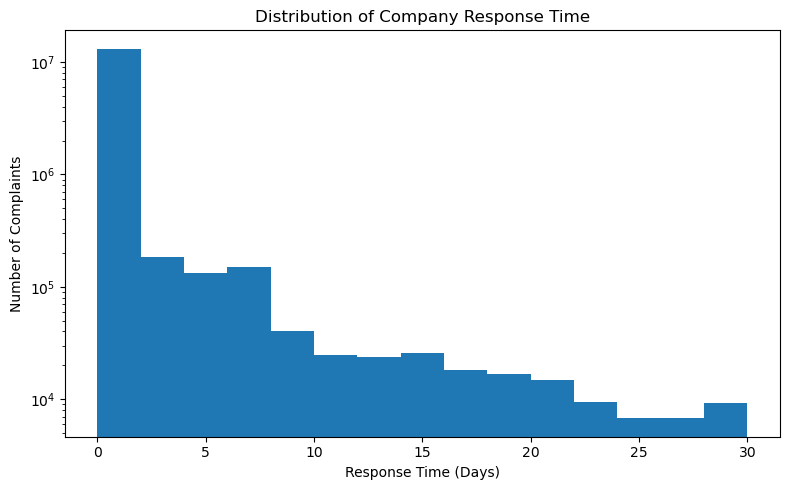

In [19]:
plt.figure(figsize=(8,5))

plt.hist(df_plot['response_time'], bins=15)

plt.xlabel("Response Time (Days)")
plt.ylabel("Number of Complaints")
plt.title("Distribution of Company Response Time")

plt.yscale('log')   # THIS IS THE KEY FIX

plt.tight_layout()
plt.savefig("final_histogram.png", dpi=300)
plt.show()